# A matrix model with SU(3) matrices

*Aug 31, 2026*

**[Javad Komijani](mailto:jkomijani@gmail.com)**

For a short review of the method of normalizing flows, see
J. Komijani and M. K. Marinković,
[arXiv:2301.01504](https://arxiv.org/abs/2301.01504), and references
therein.

The `normflow` package supports two complementary ways to train a flow:
*self-learning*, by minimizing the (reverse) KL divergence against a known
action (no data needed), and *data-based* training, by direct maximum
likelihood on a set of samples (no action needed). This notebook is in two
parts: **Part 1** trains a flow self-learning style against the action
defined below; **Part 2** then trains a second, independent flow purely from
data -- samples drawn from the Part 1 model, standing in for real data --
without the action ever entering the training itself.

## Setup: a single SU(N) matrix

Consider a single random matrix $U \in \mathrm{SU}(N)$, distributed according to

$$
p(U) \propto \exp\left(\frac{\beta}{N} \mathrm{ReTr}(U)\right)
$$

with respect to the Haar measure on $\mathrm{SU}(N)$. This is as simple
as a lattice-gauge-theory-like model can get: a single link from a point back to itself with a
Wilson-loop-like action. It is a natural first target for a flow-based
sampler on a compact, non-abelian group.

**On the idea.** Applying flow-based models to $\mathrm{SU}(N)$-valued variables was first proposed in

> D. Boyda, G. Kanwar, S. Racanière, D. J. Rezende, M. S. Albergo, K. Cranmer,
> D. C. Hackett, and P. E. Shanahan,
> Phys. Rev. D **103**, 074504 (2021),
> [arXiv:2008.05456](https://arxiv.org/abs/2008.05456).

The particular parameterization of the SU(3) eigenvalues used below (in terms
of two angles, $\theta$ and $\phi$) follows

> J. Komijani and M. K. Marinković,
> [arXiv:2501.18288](https://arxiv.org/abs/2501.18288).

**On naming.** "Normalizing flow" carries two different readings of
"normalizing": flowing *to* a normal (Gaussian) distribution, or keeping
the density properly *normalized* at each step via the change-of-variables
Jacobian. Under the first reading the name is odd here: on a compact group
like $\mathrm{SU}(N)$ there is no Gaussian to normalize toward, and the
natural reference measure is the Haar measure instead -- exactly what the
flow below is trained to connect to $p(U)$. The second reading is
unaffected, since the Jacobian correction works the same way regardless of
the base measure. Names such as *trivializing flow* (echoing Lüscher's
*trivializing maps*, M. Lüscher, Commun. Math. Phys. **293**, 899 (2010),
[arXiv:0907.5491](https://arxiv.org/abs/0907.5491)), *Haarizing flow*, or
*uniformizing flow* would describe the compact-group case more precisely
than the Gaussian-flavored reading of "normalizing flow".

---

## Part 1: Self-Learning

We start by training the flow directly against the action defined above, via
the (reverse) KL divergence -- no data required, just the ability to evaluate
$p(U)$ up to normalization.

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
if torch.cuda.is_available():                                                   
    torch.set_default_device('cuda')

grab = lambda x: x.detach().cpu().numpy()

### Set up a module for transformation

The general recipe for building a flow on a Lie group is:
1. parameterize the eigenvalues of a group element with a handful of real parameters,
2. run an ordinary real-valued flow on those parameters (here, a rational quadratic spline, `RQSplineNet_`),
3. map back to the group.

`MatrixModule_` implements this recipe given a `matrix_handle` that knows how to go back and forth
between $\mathrm{SU}(N)$ and its coordinates: one angle $\theta$ for SU(2),
two angles $\theta$ and $\phi$ for SU(3), following the parameterization
cited above. For a discussion on parameterization see [arXiv:2501.18288](https://arxiv.org/abs/2501.18288).

In [3]:
from normflow.nn import MultiChannelModule_
from normflow.nn import MatrixModule_
from normflow.nn import RQSplineNet_

from normflow.lib.matrix_handles import SU2MatrixParametrizer
from normflow.lib.matrix_handles import SU3MatrixParametrizer


def assemble_net_su2(num_spline_segments: int):
    """
    Build a network using one RQ spline for one angle (θ).
    """
    param_net_ = RQSplineNet_(num_spline_segments)
    matrix_handle = SU2MatrixParametrizer()
    return MatrixModule_(param_net_, matrix_handle=matrix_handle)


def assemble_net_su3(num_spline_segments: int):
    """
    Build a network using two RQ spline for two angles (θ, φ).
    """
    net_theta_ = RQSplineNet_(num_spline_segments)    
    net_phi_ = RQSplineNet_(num_spline_segments // 2, symmetric=True)
    param_net_ = MultiChannelModule_([net_theta_, net_phi_], channels_axis=-1)
    matrix_handle = SU3MatrixParametrizer()
    return MatrixModule_(param_net_, matrix_handle=matrix_handle)

### Put components together to make a model

For the self-learning method, three components are needed:
1. `UniformSUnPrior` draws from the Haar measure on $\mathrm{SU}(N)$ -- the reference distribution the flow starts from.
2. `MatrixModule_` implements the transformation.
3. `MatrixAction` implements the action $S(U) = -\frac{\beta}{N}\mathrm{ReTr}(U)$ defined above.

A high-level class called `Model` bundles the components together and can train the network by minimizing the (reverse) KL divergence between the flow's output and $p(U) \propto e^{-S(U)}$ -- no training data required.

**A remark on `Model`:** its `trainer` adapts to what is provided -- if an
action is given, training is self-learning, minimizing the (reverse) KL
divergence directly with no data required (as in Part 1 below); if no
action is given, training is data-based, maximizing the likelihood of a
provided dataset instead (as in Part 2). Either way, training is triggered
the same way, via `model.train(*args, **kwargs)` -- the only difference is
that the data-based case takes a data loader among those arguments, while
the self-learning case does not. (`model.train` is simply a short alias for
`model.trainer.run_training`; `model.fit` is another alias for the same
method.)

In [4]:
from normflow import Model

from normflow.action import MatrixAction

from normflow.prior import UniformSUnPrior

In [5]:
def make_normflow_model(n_c, beta, num_spline_segments):
    """The main function for building the model."""
    
    # Define the prior distribution
    prior = UniformSUnPrior(n=n_c)
    
    # Define the action
    action = MatrixAction(beta=beta)
    
    # Initialize the neural network for transformations
    if n_c == 2:
        net_ = assemble_net_su2(num_spline_segments)
    elif n_c == 3:
        net_ = assemble_net_su3(num_spline_segments)
    else:
        raise ValueError(f"n_c = {n_c} is not implemented")
    
    # Create the Model with the defined components
    model = Model(network_fn_=net_, prior=prior, action=action)
    
    return model

In [6]:
# Action parameters
n_c = 3
beta = 6

# Instantiate the model
model = make_normflow_model(n_c=n_c, beta=beta, num_spline_segments=4)

In [7]:
load_pretrained_model = True

if load_pretrained_model:

    assert n_c == 3, "The pretrained model is for SU(3)"
    
    weights_blob = 'UEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAQABIAYXJjaGl2ZS9kYXRhLnBrbEZCDgBaWlpaWlpaWlpaWlpaWoACY2NvbGxlY3Rpb25zCk9yZGVyZWREaWN0CnEAKVJxAShYFgAAAHBhcmFtX25ldF8uMC53ZWlnaHRzX3hxAmN0b3JjaC5fdXRpbHMKX3JlYnVpbGRfdGVuc29yX3YyCnEDKChYBwAAAHN0b3JhZ2VxBGN0b3JjaApGbG9hdFN0b3JhZ2UKcQVYAQAAADBxBlgDAAAAY3B1cQdLBHRxCFFLAEsEhXEJSwGFcQqJaAApUnELdHEMUnENWBYAAABwYXJhbV9uZXRfLjAud2VpZ2h0c195cQ5oAygoaARoBVgBAAAAMXEPaAdLBHRxEFFLAEsEhXERSwGFcRKJaAApUnETdHEUUnEVWBYAAABwYXJhbV9uZXRfLjAud2VpZ2h0c19kcRZoAygoaARoBVgBAAAAMnEXaAdLBXRxGFFLAEsFhXEZSwGFcRqJaAApUnEbdHEcUnEdWBYAAABwYXJhbV9uZXRfLjEud2VpZ2h0c194cR5oAygoaARoBVgBAAAAM3EfaAdLAnRxIFFLAEsChXEhSwGFcSKJaAApUnEjdHEkUnElWBYAAABwYXJhbV9uZXRfLjEud2VpZ2h0c195cSZoAygoaARoBVgBAAAANHEnaAdLAnRxKFFLAEsChXEpSwGFcSqJaAApUnErdHEsUnEtWBYAAABwYXJhbV9uZXRfLjEud2VpZ2h0c19kcS5oAygoaARoBVgBAAAANXEvaAdLA3RxMFFLAEsDhXExSwGFcTKJaAApUnEzdHE0UnE1dX1xNlgJAAAAX21ldGFkYXRhcTdoAClScTgoWAAAAABxOX1xOlgHAAAAdmVyc2lvbnE7SwFzWAoAAABwYXJhbV9uZXRfcTx9cT1oO0sBc1gMAAAAcGFyYW1fbmV0Xy4wcT59cT9oO0sBc1gUAAAAcGFyYW1fbmV0Xy4wLnNvZnRtYXhxQH1xQWg7SwFzWBUAAABwYXJhbV9uZXRfLjAuc29mdHBsdXNxQn1xQ2g7SwFzWAwAAABwYXJhbV9uZXRfLjFxRH1xRWg7SwFzWBQAAABwYXJhbV9uZXRfLjEuc29mdG1heHFGfXFHaDtLAXNYFQAAAHBhcmFtX25ldF8uMS5zb2Z0cGx1c3FIfXFJaDtLAXN1c2IuUEsHCBvt06FWAwAAVgMAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAFwAlAGFyY2hpdmUvLmZvcm1hdF92ZXJzaW9uRkIhAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjFQSwcIt+/cgwEAAAABAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAaADcAYXJjaGl2ZS8uc3RvcmFnZV9hbGlnbm1lbnRGQjMAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaNjRQSwcIP3dx6QIAAAACAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAARAD8AYXJjaGl2ZS9ieXRlb3JkZXJGQjsAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpsaXR0bGVQSwcIhT3jGQYAAAAGAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOAD4AYXJjaGl2ZS9kYXRhLzBGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjwQwD5WXpE++63hvNa6v75QSwcIG2yC+BAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOADQAYXJjaGl2ZS9kYXRhLzFGQjAAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaxQasvhKdaL6VJpa9ckWsPlBLBwghTWvTEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4ANABhcmNoaXZlL2RhdGEvMkZCMABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlr+7oS/Fu9sv4p0s74/rnA/9mVCQFBLBwiZtcnnFAAAABQAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4AMABhcmNoaXZlL2RhdGEvM0ZCLABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWqIyXTxPN128UEsHCI2i5kkIAAAACAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgA8AGFyY2hpdmUvZGF0YS80RkI4AFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaftfSu4HY0jtQSwcITh4HXggAAAAIAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOADwAYXJjaGl2ZS9kYXRhLzVGQjgAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlq5pna9zLpJuWj/qT1QSwcI49QNMgwAAAAMAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADcAYXJjaGl2ZS92ZXJzaW9uRkIzAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjMKUEsHCNGeZ1UCAAAAAgAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAHgAyAGFyY2hpdmUvLmRhdGEvc2VyaWFsaXphdGlvbl9pZEZCLgBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaMTExMTg5NzkxMTA1NTMwMjYxMDExNDkyMjA3OTg2MDM2NTQxNzY0MFBLBwiBcVUsKAAAACgAAABQSwECAAAAAAgIAAAAAAAAG+3ToVYDAABWAwAAEAAAAAAAAAAAAAAAAAAAAAAAYXJjaGl2ZS9kYXRhLnBrbFBLAQIAAAAACAgAAAAAAAC379yDAQAAAAEAAAAXAAAAAAAAAAAAAAAAAKYDAABhcmNoaXZlLy5mb3JtYXRfdmVyc2lvblBLAQIAAAAACAgAAAAAAAA/d3HpAgAAAAIAAAAaAAAAAAAAAAAAAAAAABEEAABhcmNoaXZlLy5zdG9yYWdlX2FsaWdubWVudFBLAQIAAAAACAgAAAAAAACFPeMZBgAAAAYAAAARAAAAAAAAAAAAAAAAAJIEAABhcmNoaXZlL2J5dGVvcmRlclBLAQIAAAAACAgAAAAAAAAbbIL4EAAAABAAAAAOAAAAAAAAAAAAAAAAABYFAABhcmNoaXZlL2RhdGEvMFBLAQIAAAAACAgAAAAAAAAhTWvTEAAAABAAAAAOAAAAAAAAAAAAAAAAAKAFAABhcmNoaXZlL2RhdGEvMVBLAQIAAAAACAgAAAAAAACZtcnnFAAAABQAAAAOAAAAAAAAAAAAAAAAACAGAABhcmNoaXZlL2RhdGEvMlBLAQIAAAAACAgAAAAAAACNouZJCAAAAAgAAAAOAAAAAAAAAAAAAAAAAKQGAABhcmNoaXZlL2RhdGEvM1BLAQIAAAAACAgAAAAAAABOHgdeCAAAAAgAAAAOAAAAAAAAAAAAAAAAABgHAABhcmNoaXZlL2RhdGEvNFBLAQIAAAAACAgAAAAAAADj1A0yDAAAAAwAAAAOAAAAAAAAAAAAAAAAAJgHAABhcmNoaXZlL2RhdGEvNVBLAQIAAAAACAgAAAAAAADRnmdVAgAAAAIAAAAPAAAAAAAAAAAAAAAAABwIAABhcmNoaXZlL3ZlcnNpb25QSwECAAAAAAgIAAAAAAAAgXFVLCgAAAAoAAAAHgAAAAAAAAAAAAAAAACSCAAAYXJjaGl2ZS8uZGF0YS9zZXJpYWxpemF0aW9uX2lkUEsGBiwAAAAAAAAAHgMtAAAAAAAAAAAADAAAAAAAAAAMAAAAAAAAAPsCAAAAAAAAOAkAAAAAAABQSwYHAAAAADMMAAAAAAAAAQAAAFBLBQYAAAAADAAMAPsCAAA4CQAAAAA='
    model.network_fn_.set_weights_blob(weights_blob)
    
else:
    
    model.train(n_epochs=1000, batch_size=128, hyperparam={'lr': 0.01})

In [8]:
# Compute and print Effective Sample Size (ESS)
ess = model.compute_metrics(batch_size=1024)[0]                       
print(f"\nESS: {ess}\n")


ESS: 0.9998998641967773



In [9]:
if not load_pretrained_model:
    
    fig, axs = plt.subplots(1, 1, figsize=(6, 4))

    log_dict = model.trainer.logger.load_numpy()
    plt.plot(log_dict['epoch'], log_dict['loss'], '-')

### Illustrate the eigenangles

The eigenvalues of $U \in \mathrm{SU}(N)$ lie on the unit circle with product
fixed to 1; their phases (eigenangles) are gauge-invariant observables. For
SU(3) with the action above, the marginal distribution of a single eigenangle
has a known closed form (`su3_phase_marginal_dist`), giving us a clean,
independent check of the trained flow.

In [10]:
from normflow.lib.matrix_handles import su3_phase_marginal_dist

from lattice_ml.linalg import eigu

In [11]:
# Sample from the trained model
# As ESS is close to 1, we neglect any bias corrections

x, logr = model.prior.sample_(batch_size=1024 * 128)

with torch.no_grad():
    y, logj = model.network_fn_(x)

angles_x = grab(torch.angle(eigu(x)[0]))
angles_y = grab(torch.angle(eigu(y)[0]))

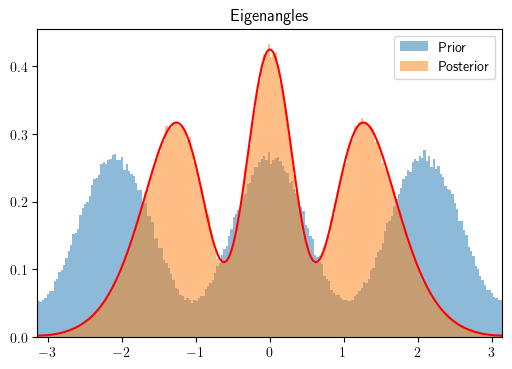

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

plt.hist(angles_x.ravel(), density=True, bins=200, alpha=0.5, label='Prior')
plt.hist(angles_y.ravel(), density=True, bins=200, alpha=0.5, label='Posterior')
plt.xlim([-torch.pi, torch.pi])
plt.title("Eigenangles")
plt.legend()


# Add analytic results for SU(3)
x_0, pdf_0 = su3_phase_marginal_dist(model.action, bins=200)
x_0, pdf_0 = grab(x_0), grab(pdf_0)
plt.plot(x_0, pdf_0, color='r');

### Plot log-probabilities

A standard diagnostic for a trained flow: plot $\log q(y) = \log r(x) -
\log J$ (the flow's own log-density) against $\log p(y) = -S(y)$ (the target,
up to normalization) for samples $y$ drawn from the flow. A well-trained flow
should place these points along a single diagonal line, $\log p = \log q +
\text{const}$, with a small scatter around it -- consistent with the ESS
computed above.

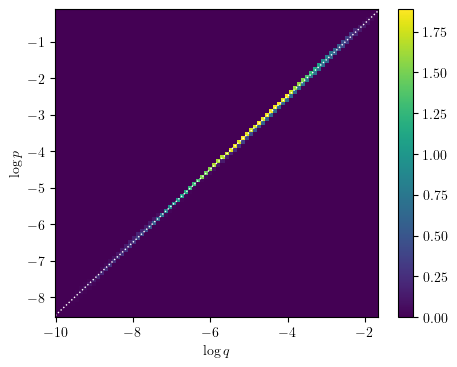

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5.2, 4))

logq = logr - logj
logp = - model.action(y)

plt.hist2d(grab(logq), grab(logp), bins=80, density=True)
plt.xlabel(r'$\log q$')
plt.ylabel(r'$\log p$')
plt.colorbar()

    
# Diagonal: logp = logq + constant 
xmin = logq.min()
xmax = logq.max()

shift = logp.mean() - logq.mean()
plt.plot([xmin, xmax], [xmin + shift, xmax + shift], 'w:', linewidth=1);

# fig.savefig("SU3_logq_logp.pdf", dpi=600)

---

## Part 2: Training with data

So far the flow above was trained "self-learning" style: by minimizing the
(reverse) KL divergence against a known action, with no data required.
`normflow` also supports the complementary, data-based mode of training:
given a set of i.i.d. samples from the target distribution -- and no
knowledge of the action at all -- the flow can instead be trained by direct
maximum likelihood, exactly as one would train a flow on any other dataset.

To demonstrate this without a separate lattice dataset on hand, we treat the
self-learned model above as a stand-in for a real data source: we draw MCMC
samples from it (`model.mcmc.sample`), which are asymptotically unbiased
samples from the true target $p(U)$, and use those samples as the "data" to
train a fresh model from scratch below.

In [14]:
# A fresh, untrained network with the same prior as before -- note there
# is no action this time: this model will be trained purely from data
databased_model = Model(
    network_fn_=assemble_net_su3(num_spline_segments=4),
    prior=UniformSUnPrior(n=n_c)
)

In [15]:
# Stand-in for real data: draw (asymptotically unbiased) MCMC samples
# from the self-learned model above -- these will be our training "data"
training_samples = model.mcmc.sample(1024 * 4)

print("shape of training data", training_samples.shape)

shape of training data torch.Size([4096, 3, 3])


In [16]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Wrap the samples in the usual PyTorch Dataset/DataLoader machinery
batch_size = 128

dataset = TensorDataset(training_samples)
data_loader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)

In [17]:
n_epochs = 300

In [18]:
# Train by maximum likelihood on the data loader -- no action involved
databased_model.train(data_loader, n_epochs=n_epochs, hyperparam={'lr': 0.01})


  | Name       | Type                 | Params | Mode 
------------------------------------------------------
0 | network_fn | MatrixModule_        | 20     | train
------------------------------------------------------
20	Trainable params
0	Non-trainable params
20	Total params

Default dtype: torch.float32



100%|█████████████████████████████████████████████████████████████████████| 300/300 [00:17<00:00, 16.71it/s]


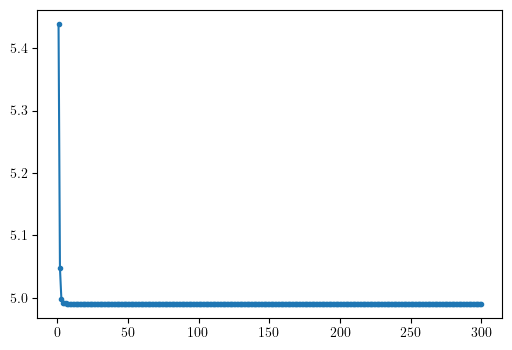

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

log_dict = databased_model.trainer.logger.load_numpy()
plt.plot(log_dict['epoch'], log_dict['loss'], '.-');

In [20]:
# Sample from the data-trained model. With no action, there is nothing
# to reweight against (no ESS, no bias correction) -- these samples are
# taken at face value

x, logr = databased_model.prior.sample_(batch_size=1024 * 128)

with torch.no_grad():
    y, logj = databased_model.network_fn_(x)

angles_x = grab(torch.angle(eigu(x)[0]))
angles_y = grab(torch.angle(eigu(y)[0]))

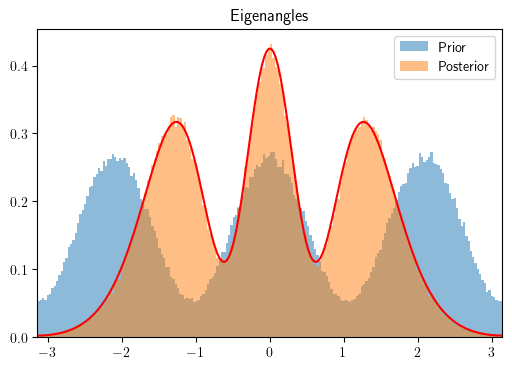

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

plt.hist(angles_x.ravel(), density=True, bins=200, alpha=0.5, label='Prior')
plt.hist(angles_y.ravel(), density=True, bins=200, alpha=0.5, label='Posterior')
plt.xlim([-torch.pi, torch.pi])
plt.title("Eigenangles")
plt.legend()


# For comparison, overlay the analytic target computed from the true
# action (model.action) -- databased_model itself never saw this action
x_0, pdf_0 = su3_phase_marginal_dist(model.action, bins=200)
x_0, pdf_0 = grab(x_0), grab(pdf_0)
plt.plot(x_0, pdf_0, color='r');